In [3]:
import pandas as pd


In [7]:
!pip install catboost -q
import numpy as np
from catboost import CatBoostRegressor, Pool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


#Data prep

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [164]:
df_train = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/train_clean.csv", low_memory=False)
y_train = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/train_targets.csv", low_memory=False)
df_valid = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/valid_clean.csv", low_memory=False)
y_valid = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/valid_targets.csv", low_memory=False)

In [76]:
df_train.columns


Index(['cust_id', 'order_date', 'sale_id', 'sale_discount_applied',
       'sale_revenue', 'prod_id', 'prod_size', 'prod_web_only', 'prod_brand',
       'prod_color', 'prod_type_1', 'prod_type_3', 'prod_type_4',
       'prod_type_5', 'prod_material', 'prod_insole', 'prod_outlet',
       'order_month', 'order_day', 'is_jan', 'is_july', 'original_price',
       'discount_pct', 'discount_flag', 'season_year', 'is_NOS', 'is_CONS',
       'prod_type_3_list', 'low_heel', 'high_heel', 'heel_unknown',
       'material_list', 'n_materials', 'comfort_sole_list',
       'n_comfort_features', 'comfort_wear_list', 'n_comfort_wear',
       'has_print', 'clasp_list', 'n_clasps', 'is_returned'],
      dtype='object')

In [ ]:
df_train["order_month"] = df_train["order_month"].astype(str)
df_train["order_day"] = df_train["order_day"].astype(str)
df_train['is_weekend'] = df_train['order_date'].dt.weekday >= 5

In [159]:
df_valid["order_month"] = df_valid["order_month"].astype(str)
df_valid["order_day"] = df_valid["order_day"].astype(int)
df_valid["is_weekend"] = df_valid["order_day"] >= 5
df_valid["order_day"] = df_valid["order_day"].astype(str)

In [160]:
def aggregate_customer_data(df):
    df['order_date'] = pd.to_datetime(df['order_date'])

    # 1. Define aggregations (Combined duplicates into lists)
    aggregations = {
        'sale_revenue': ['sum', 'mean','std'],
        'sale_id': 'nunique',
        'prod_id': 'count',
        'sale_discount_applied': 'mean',
        'discount_pct': 'mean',
        'prod_size': ['mean', 'nunique','std'],
        'n_comfort_features': 'mean',
        'n_comfort_wear': 'mean',
        'n_clasps': 'mean',
        'n_materials': 'mean',
        'prod_web_only': 'mean',
        'prod_outlet': 'mean',
        'is_NOS': 'mean',
        'is_CONS': 'mean',
        'is_returned': 'mean',
        'discount_flag': 'mean',
        'has_print': 'mean',
        'is_jan': 'mean',
        'is_july': 'mean',
        'low_heel': 'mean',
        'high_heel': 'mean',
        'heel_unknown': 'mean',
        'prod_brand': [lambda x: x.mode().iloc[0] if not x.mode().empty else "Missing", 'nunique'],
        'prod_color': [lambda x: x.mode().iloc[0] if not x.mode().empty else "Missing",'nunique'],
        'prod_type_1': [lambda x: x.mode().iloc[0] if not x.mode().empty else "Missing", 'nunique'],
        'prod_type_3': lambda x: x.mode().iloc[0] if not x.mode().empty else "Missing",
        'prod_material': lambda x: x.mode().iloc[0] if not x.mode().empty else "Missing",
        'order_date': ['min', 'max'],
        'order_month': 'nunique',
        'order_day': 'nunique',
        'is_weekend': 'mean',
    }

    # 2. Perform the GroupBy
    cust_df = df.groupby('cust_id').agg(aggregations)

    # 3. Flatten the columns
    # Order matches the keys in 'aggregations' above
    cust_df.columns = [
        'total_revenue', 'avg_revenue', 'std_revenue','n_transactions', 'n_items_total',
        'avg_discount_applied', 'avg_discount_pct', 'avg_size', 'n_unique_sizes','std_size',
        'avg_comfort_features', 'avg_comfort_wear', 'avg_clasps', 'avg_materials',
        'pct_web_only', 'pct_outlet', 'pct_nos', 'pct_cons', 'return_rate',
        'pct_discount_flag', 'pct_print', 'pct_jan', 'pct_july',
        'pct_low_heel', 'pct_high_heel', 'pct_heel_unknown',
        'fav_brand', 'n_brands', 'fav_color','n_colors', 'fav_type_1', 'n_types_1',
        'fav_type_3', 'fav_material', 'first_order_date', 'last_order_date', 'n_months',
        'n_days', 'pct_weekend'
    ]
    max_date = df['order_date'].max()

    cust_df['recency_days'] = (max_date - cust_df['last_order_date']).dt.days
    cust_df['customer_lifetime_days'] = (cust_df['last_order_date'] - cust_df['first_order_date']).dt.days.clip(lower=1)
    cust_df['recency_ratio'] = cust_df['recency_days'] / cust_df['customer_lifetime_days']
    cust_df['frequency'] = cust_df['n_transactions'] / cust_df['customer_lifetime_days'].clip(lower=1)
    cust_df['avg_days_between_orders'] = cust_df['customer_lifetime_days'] / cust_df['n_transactions'].clip(lower=1)
    cust_df['brand_diversity'] = cust_df['n_brands'] / cust_df['n_transactions'].clip(lower=1)

    return cust_df.reset_index()

In [161]:
customer_train_df = aggregate_customer_data(df_train)
customer_valid_df = aggregate_customer_data(df_valid)

In [162]:
train_final = customer_train_df.merge(y_train, on='cust_id', how='inner')
train_final['target_log'] = np.log1p(train_final['revenue_2018_2019'])
X_train = train_final.drop(['cust_id', 'revenue_2018_2019','churned', 'target_log'], axis=1)
y_train_log = train_final['target_log']

In [165]:
valid_final = customer_valid_df.merge(y_valid, on='cust_id', how='inner')
valid_final['target_log'] = np.log1p(valid_final['revenue_2018_2019'])
X_valid = valid_final.drop(['cust_id', 'revenue_2018_2019','churned', 'target_log'], axis=1)
y_valid_log = valid_final['target_log']

In [166]:
cat_features = ['fav_brand', 'fav_color', 'fav_type_1', 'fav_type_3', 'fav_material']

#Base catboost model - MAE: 62.12

In [167]:
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    verbose=100
)

In [168]:
train_pool = Pool(X_train, y_train_log, cat_features=cat_features)
cat_model.fit(train_pool)

0:	learn: 1.7751125	total: 308ms	remaining: 5m 7s
100:	learn: 1.4585819	total: 20.2s	remaining: 2m 59s
200:	learn: 1.4535429	total: 36.6s	remaining: 2m 25s
300:	learn: 1.4508602	total: 55.3s	remaining: 2m 8s
400:	learn: 1.4491347	total: 1m 16s	remaining: 1m 53s
500:	learn: 1.4481010	total: 1m 36s	remaining: 1m 36s
600:	learn: 1.4467514	total: 1m 52s	remaining: 1m 14s
700:	learn: 1.4457741	total: 2m 9s	remaining: 55.3s
800:	learn: 1.4448032	total: 2m 27s	remaining: 36.6s
900:	learn: 1.4441323	total: 2m 44s	remaining: 18.1s
999:	learn: 1.4428551	total: 2m 58s	remaining: 0us


CatBoostRegressor(eval_metric='MAE', iterations=1000, learning_rate=0.05, loss_function='MAE', random_seed=42, verbose=100)

In [169]:
log_preds_valid = cat_model.predict(X_valid)

In [170]:
pred_valid_rev = np.expm1(log_preds_valid)
y_valid = valid_final['revenue_2018_2019']

In [171]:
from sklearn.metrics import mean_absolute_error
real_mae = mean_absolute_error(y_valid, pred_valid_rev)

print(f"Validation MAE (Actual Scale): {real_mae:.2f}")

Validation MAE (Actual Scale): 62.22


###feature importance

In [176]:
feat_imp = final_cat.get_feature_importance(prettified=True)

feat_imp.head(20)

,Feature Id,Importances
0,n_unique_sales,44.948777
1,n_brands,32.165123
2,n_items_total,6.010804
3,avg_size,3.891641
4,total_revenue,2.499157
5,avg_materials,2.080222
6,avg_comfort_features,1.831093
7,avg_clasps,1.651542
8,fav_type_1,1.477844
9,avg_revenue,1.116114


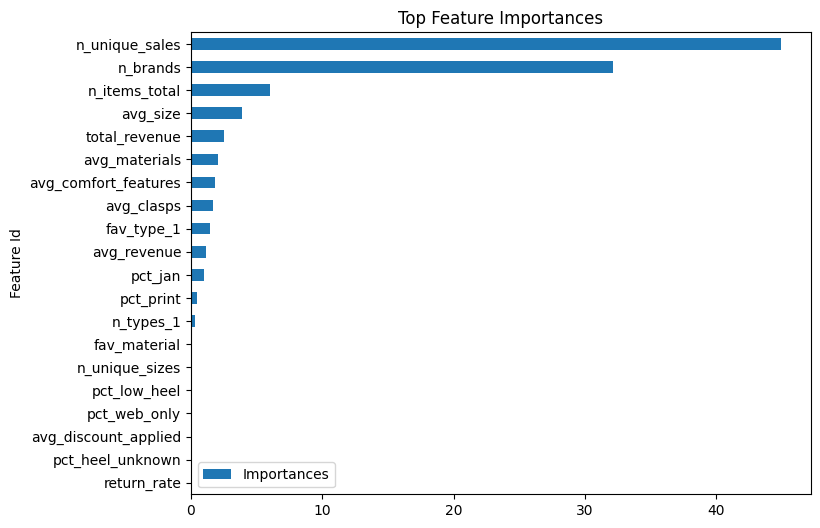

In [178]:
import matplotlib.pyplot as plt

feat_imp.sort_values("Importances").tail(20).plot(
    x="Feature Id",
    y="Importances",
    kind="barh",
    figsize=(8,6)
)

plt.title("Top Feature Importances")
plt.show()

#Tuned Catboost - MAE: 62.34

In [180]:
from catboost import CatBoostRegressor, Pool

cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features]
train_pool = Pool(X_train, y_train_log, cat_features=cat_feature_indices)

base_model = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    verbose=False
)

param_dist = {
    'depth': [6, 8, 10],              # Go deeper
    'learning_rate': [0.01, 0.03, 0.05],
    'l2_leaf_reg': [1, 3, 5, 10],     # More regularization options
    'border_count': [64, 128, 255],   # Quantile splits
    'iterations': [500, 1000]
}


In [181]:
cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features]

In [182]:
blank_cat = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    verbose=False
)

In [183]:
search_result = blank_cat.randomized_search(
    param_distributions=param_dist,
    X=train_pool,
    cv=2,               # 2-fold instead of 3
    n_iter=8,           # 8 trials instead of 20
    partition_random_seed=42,
    calc_cv_statistics=True,
    search_by_train_test_split=False,
    refit=True,
    verbose=True
)

Training on fold [0/2]

bestTest = 1.466752624
bestIteration = 482

Training on fold [1/2]

bestTest = 1.46505083
bestIteration = 460

0:	loss: 1.4660473	best: 1.4660473 (0)	total: 4m 44s	remaining: 33m 12s
Training on fold [0/2]

bestTest = 1.468691375
bestIteration = 99

Training on fold [1/2]

bestTest = 1.469071129
bestIteration = 94

1:	loss: 1.5141519	best: 1.4660473 (0)	total: 15m 38s	remaining: 46m 56s
Training on fold [0/2]

bestTest = 1.464985412
bestIteration = 333

Training on fold [1/2]

bestTest = 1.462488021
bestIteration = 389

2:	loss: 1.4645402	best: 1.4645402 (2)	total: 17m 31s	remaining: 29m 12s
Training on fold [0/2]

bestTest = 1.465358986
bestIteration = 622

Training on fold [1/2]

bestTest = 1.463261012
bestIteration = 749

3:	loss: 1.4652236	best: 1.4645402 (2)	total: 21m 19s	remaining: 21m 19s
Training on fold [0/2]

bestTest = 1.465316171
bestIteration = 497

Training on fold [1/2]

bestTest = 1.464427724
bestIteration = 497

4:	loss: 1.4648819	best: 1.46454

In [185]:
best_params = search_result['params'].copy()
best_params.update({
    'iterations': 1000,        # or 1000 if time allows
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'verbose': 100
})

In [186]:
final_cat = CatBoostRegressor(**best_params)
final_cat.fit(
    X_train, y_train_log,
    cat_features=cat_feature_indices,
    eval_set=(X_valid, y_valid_log),
    early_stopping_rounds=50
)

0:	learn: 1.7750500	test: 1.7740121	best: 1.7740121 (0)	total: 185ms	remaining: 3m 4s
100:	learn: 1.4676996	test: 1.4566864	best: 1.4566864 (100)	total: 18.3s	remaining: 2m 43s
200:	learn: 1.4636021	test: 1.4548532	best: 1.4548377 (198)	total: 35.3s	remaining: 2m 20s
300:	learn: 1.4583129	test: 1.4521888	best: 1.4521888 (300)	total: 53.9s	remaining: 2m 5s
400:	learn: 1.4532624	test: 1.4502761	best: 1.4502761 (400)	total: 1m 14s	remaining: 1m 51s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.450066192
bestIteration = 436

Shrink model to first 437 iterations.


CatBoostRegressor(border_count=128, depth=6, eval_metric='MAE', iterations=1000, l2_leaf_reg=3, learning_rate=0.05, loss_function='MAE', random_seed=42, verbose=100)

In [187]:
log_preds_valid = final_cat.predict(X_valid)
pred_valid_rev = np.expm1(log_preds_valid)
y_valid = valid_final['revenue_2018_2019']

In [188]:
mae_final = mean_absolute_error(y_valid, pred_valid_rev)
print(f"Final tuned CatBoost MAE (actual scale): {mae_final:.2f}")

Final tuned CatBoost MAE (actual scale): 62.34


##residuals

In [45]:
import pandas as pd
import numpy as np

# Assuming you already have:
# final_cat_model, X_valid, y_valid (actual revenue), and valid_final with cust-level features

log_pred_valid = final_cat.predict(X_valid)
pred_valid = np.expm1(log_pred_valid)

residuals = y_valid.values - pred_valid
residuals_abs = np.abs(residuals)

res_df = valid_final.copy()
res_df['pred_rev'] = pred_valid
res_df['residual'] = residuals
res_df['abs_residual'] = residuals_abs


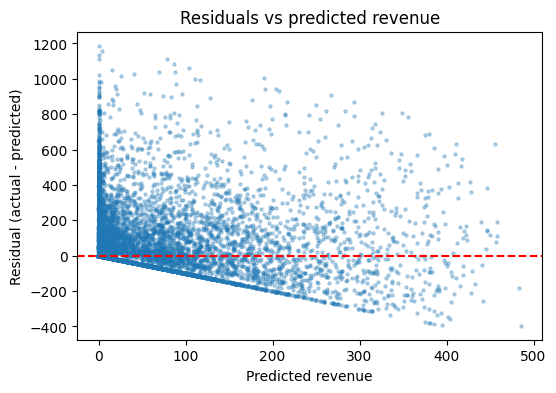

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(res_df['pred_rev'], res_df['residual'], alpha=0.3, s=5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted revenue")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs predicted revenue")
plt.show()

#Clustering + Catboost

##K-means clustering

In [48]:
num_features = [c for c in X_train.columns if c not in cat_features]
X_train_num = X_train[num_features].copy()
X_valid_num = X_valid[num_features].copy()

In [50]:
for col in num_features:
    # Replace inf with NaN, then fill with median
    X_train_num[col] = X_train_num[col].replace([np.inf, -np.inf], np.nan)
    X_valid_num[col] = X_valid_num[col].replace([np.inf, -np.inf], np.nan)

    # Fill NaN with median
    median_val = X_train_num[col].median()
    X_train_num[col] = X_train_num[col].fillna(median_val)
    X_valid_num[col] = X_valid_num[col].fillna(median_val)

    # Cap extreme values (99.9th percentile)
    upper = X_train_num[col].quantile(0.999)
    lower = X_train_num[col].quantile(0.001)
    X_train_num[col] = np.clip(X_train_num[col], lower, upper)
    X_valid_num[col] = np.clip(X_valid_num[col], lower, upper)

/tmp/ipykernel_235/4103996880.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_num[col] = X_train_num[col].replace([np.inf, -np.inf], np.nan)
/tmp/ipykernel_235/4103996880.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_valid_num[col] = X_valid_num[col].replace([np.inf, -np.inf], np.nan)
/tmp/ipykernel_235/4103996880.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_valid_scaled = scaler.transform(X_valid_num)

In [66]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_scaled)
valid_clusters = kmeans.predict(X_valid_scaled)

In [67]:
train_final['cluster'] = train_clusters
valid_final['cluster'] = valid_clusters

##clustered Cat boost - MAE: 62.87

In [71]:
rom sklearn.model_selection import KFold

In [68]:
def tune_catboost_per_cluster_cv(X_c, y_c, cat_features, n_splits=3):
    param_grid = {
        'depth': [4, 6, 8],
        'learning_rate': [0.03, 0.05],
        'l2_leaf_reg': [3, 5, 7],
        'bagging_temperature': [0.0, 0.5]
    }

    best_mae = np.inf
    best_params = None
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for params in ParameterGrid(param_grid):
        cv_maes = []
        for train_idx, val_idx in kf.split(X_c):
            # Split cluster data into internal train/val folds
            X_t, X_v = X_c.iloc[train_idx], X_c.iloc[val_idx]
            y_t, y_v = y_c.iloc[train_idx], y_c.iloc[val_idx]

            model = CatBoostRegressor(
                iterations=400, # Faster tuning
                **params,
                loss_function='MAE',
                random_seed=42,
                verbose=False
            )
            model.fit(X_t, y_t, cat_features=cat_features)

            # Score on the internal fold (Actual Scale)
            preds = np.expm1(model.predict(X_v))
            actuals = np.expm1(y_v)
            cv_maes.append(mean_absolute_error(actuals, preds))

        avg_mae = np.mean(cv_maes)
        if avg_mae < best_mae:
            best_mae = avg_mae
            best_params = params

    return best_params

In [69]:
tuned_cluster_models = {}
global_fallback_model = final_cat

In [72]:
for c in range(best_k):
    mask = (train_clusters == c)
    n_cust = mask.sum()

    if n_cust < 500:
        print(f"Cluster {c} too small ({n_cust}). Using Global Fallback.")
        continue

    print(f"Tuning and Fitting Cluster {c} (n={n_cust})...")
    X_c, y_c = X_train.iloc[mask], y_train_log.iloc[mask]

    # Get best params via CV
    best_p = tune_catboost_per_cluster_cv(X_c, y_c, cat_feature_indices)

    # Fit final cluster model on all cluster data
    m = CatBoostRegressor(iterations=1000, **best_p, loss_function='MAE', verbose=False)
    m.fit(X_c, y_c, cat_features=cat_feature_indices)
    tuned_cluster_models[c] = m

Tuning and Fitting Cluster 0 (n=71450)...
Tuning and Fitting Cluster 1 (n=5940)...
Tuning and Fitting Cluster 2 (n=15882)...


In [73]:
log_preds_valid = np.zeros(len(X_valid))

for i in range(len(X_valid)):
    cluster_id = valid_clusters[i]

    if cluster_id in tuned_cluster_models:
        # Use specialized model
        log_preds_valid[i] = tuned_cluster_models[cluster_id].predict(X_valid.iloc[i])
    else:
        # Use global fallback for cluster 3 or other unknowns
        log_preds_valid[i] = global_fallback_model.predict(X_valid.iloc[i])

In [74]:
pred_valid_rev = np.expm1(log_preds_valid)
y_valid_actual = valid_final['revenue_2018_2019']
final_mae = mean_absolute_error(y_valid_actual, pred_valid_rev)

print(f"Corrected Clustered MAE: {final_mae:.2f}")

Corrected Clustered MAE: 62.82


In [75]:
import pandas as pd
import matplotlib.pyplot as plt

def get_cluster_importances(model, feature_names):
    """Extracts and returns sorted feature importance for a CatBoost model"""
    importances = model.get_feature_importance()
    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    return feat_imp_df

# Example: Display importance for Cluster 0
feature_names = X_train.columns
cluster_0_model = tuned_cluster_models[0]
print(get_cluster_importances(cluster_0_model, feature_names))

             Feature  Importance
2     n_transactions   35.557362
3            n_items   20.370471
6           avg_size   10.608801
14        fav_type_1    7.878420
16      fav_material    5.870042
0      total_revenue    4.506080
1    avg_order_value    3.315883
5   avg_discount_pct    2.822338
15        fav_type_3    2.805771
13         fav_color    2.609616
7       pct_web_only    1.662737
4     total_discount    1.604378
9            pct_nos    0.305165
8         pct_outlet    0.032554
11       return_rate    0.026051
10          pct_cons    0.024329
12         fav_brand    0.000000


##Catboost per cluster - MAE: 62.82

In [54]:
cluster_models = {}
cat_feature_indices = [X_train.columns.get_loc(c) for c in cat_features]

In [55]:
for c in range(best_k):
    mask = train_clusters == c
    n_cust = mask.sum()
    if n_cust < 500:
        print(f"Skipping cluster {c}: too small ({n_cust} customers)")
        continue

    print(f"Training cluster {c} (n={n_cust})")
    X_c = X_train.iloc[mask]
    y_c = y_train_log.iloc[mask]

    model_c = CatBoostRegressor(
        iterations=800, learning_rate=0.05, depth=6,
        l2_leaf_reg=5, bagging_temperature=0.5,
        loss_function='MAE', eval_metric='MAE',
        random_seed=42, verbose=False
    )
    model_c.fit(X_c, y_c, cat_features=cat_feature_indices)
    cluster_models[c] = model_c

Training cluster 0 (n=67828)
Training cluster 1 (n=6077)
Training cluster 2 (n=19187)
Skipping cluster 3: too small (180 customers)


In [56]:
log_preds_valid = np.zeros(len(X_valid))
for c, model_c in cluster_models.items():
    mask = valid_clusters == c
    if mask.sum() == 0: continue
    log_preds_valid[mask] = model_c.predict(X_valid.iloc[mask])

In [57]:
pred_valid_rev = np.expm1(log_preds_valid)
y_valid = valid_final['revenue_2018_2019']
mae_clustered = mean_absolute_error(y_valid, pred_valid_rev)
print(f"Clustered CatBoost MAE: {mae_clustered:.2f}")

Clustered CatBoost MAE: 62.82


worst MAE - 62.82 => tune per cluster

In [ ]:
from sklearn.model_selection import ParameterGrid
import warnings
warnings.filterwarnings('ignore')

In [58]:
def tune_catboost_per_cluster(X_c, y_c, cat_features, n_trials=20):
    """Quick tuning for one cluster"""
    param_grid = {
        'depth': [4, 6, 8],
        'learning_rate': [0.03, 0.05, 0.08],
        'l2_leaf_reg': [3, 5, 8]
    }

    best_mae = np.inf
    best_params = None
    for params in ParameterGrid(param_grid):
        model = CatBoostRegressor(
            iterations=500,  # fewer iterations for speed
            **params,
            loss_function='MAE',
            eval_metric='MAE',
            random_seed=42,
            verbose=False
        )
        model.fit(X_c, y_c, cat_features=cat_feature_indices)
        # Use same-cluster validation for scoring
        preds = model.predict(X_valid[valid_clusters == c])
        mae = mean_absolute_error(y_valid[valid_clusters == c], np.expm1(preds))

        if mae < best_mae:
            best_mae = mae
            best_params = params

    return best_params, best_mae

In [60]:
tuned_models = {}
from sklearn.model_selection import ParameterGrid
for c in cluster_models.keys():  # only previously viable clusters
    mask = train_clusters == c
    X_c = X_train.iloc[mask]
    y_c = y_train_log.iloc[mask]

    print(f"Tuning cluster {c}...")
    best_params, best_mae = tune_catboost_per_cluster(X_c, y_c, cat_features)
    print(f"Cluster {c} best: MAE={best_mae:.2f}, params={best_params}")

Tuning cluster 0...
Cluster 0 best: MAE=46.98, params={'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Tuning cluster 1...
Cluster 1 best: MAE=183.11, params={'depth': 4, 'l2_leaf_reg': 5, 'learning_rate': 0.03}
Tuning cluster 2...
Cluster 2 best: MAE=80.17, params={'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.05}


In [61]:
final_model = CatBoostRegressor(iterations=800, **best_params,
                                  loss_function='MAE', random_seed=42, verbose=False)
final_model.fit(X_c, y_c, cat_features=cat_feature_indices)
tuned_models[c] = final_model

In [62]:
log_preds_valid = np.zeros(len(X_valid))
cluster_coverage = np.zeros(len(X_valid))

In [63]:
for c, model_c in tuned_models.items():
    mask = valid_clusters == c
    n_covered = mask.sum()
    cluster_coverage[mask] = 1

    if n_covered > 0:
        log_preds_valid[mask] = model_c.predict(X_valid.iloc[mask])

In [64]:
pred_valid_rev = np.expm1(log_preds_valid)
y_valid_rev = valid_final['revenue_2018_2019']

In [65]:
mae_clustered = mean_absolute_error(y_valid_rev, pred_valid_rev)
print(f"MAE:              {mae_clustered:.2f}")

MAE:              69.13


#Test set - MAE = 61.9 on leaderboard

In [200]:
df_test= pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/test_clean.csv", low_memory=False)

In [202]:
df_test["order_month"] = df_test["order_month"].astype(str)
df_test["order_day"] = df_test["order_day"].astype(str)
df_test['is_weekend'] = df_test['order_date'].dt.weekday >= 5

In [203]:
customer_test_df = aggregate_customer_data(df_test)
test_cust_ids = customer_test_df['cust_id']

In [204]:
X_test = customer_test_df.drop(['cust_id'], axis=1)

In [205]:
log_pred_test = cat_model.predict(X_test)

In [206]:
pred_test_rev = np.expm1(log_pred_test)

In [210]:
train_cust_ids = customer_train_df['cust_id']
log_pred_train = cat_model.predict(X_train)
pred_train_rev = np.expm1(log_pred_train)

In [212]:
submission = pd.DataFrame({
    'cust_id': test_cust_ids ,
    'prediction': pred_test_rev
})

# 3. Save competition-ready CSV (NO header, comma-separated, period decimals)
submission.to_csv(r"/content/drive/MyDrive/Colab Notebooks/cat_sub.csv", index=False, header=False)

print("Submission saved as 'cat_sub.csv'")
print("First 5 rows:")
print(submission.head())
print(f"Total predictions: {len(submission)}")

Submission saved as 'cat_sub.csv'
First 5 rows:
            cust_id    prediction
0  222wlefm7esnsi3h  1.231187e+00
1  224j2bblkxseyuux  9.841190e-02
2  224myrd7nlqdkm7j -8.049502e-07
3  224qcoczcvqlu56j  5.809530e+00
4  224rajycdiuglkxy  4.206903e-04
Total predictions: 29148


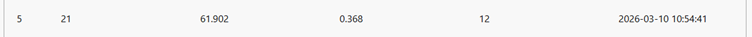

In [211]:
train_pred = pd.DataFrame({
    'cust_id': train_cust_ids ,
    'prediction': pred_train_rev
})
print(submission.head())

            cust_id    prediction
0  222wlefm7esnsi3h  1.231187e+00
1  224j2bblkxseyuux  9.841190e-02
2  224myrd7nlqdkm7j -8.049502e-07
3  224qcoczcvqlu56j  5.809530e+00
4  224rajycdiuglkxy  4.206903e-04


test = train